
# Time Series Forecasting — The Math, Explained and Implemented

The companion notebook to the animated slide deck: every model gets **the math
derived**, and **working code**, mostly built from scratch with NumPy /
statsmodels so the mechanics stay visible rather than hidden behind one
black-box `.fit()` call.

We'll build a few small synthetic series throughout — trending, seasonal, and
autoregressive — so you can see exactly which pattern each model is built to
catch.


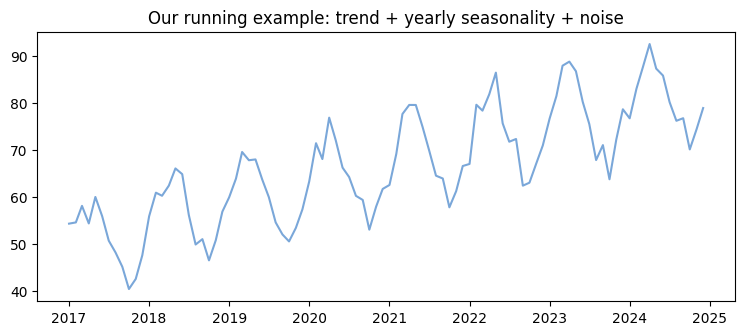

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(11)
plt.rcParams['figure.facecolor'] = 'white'

n = 96  # 8 years of monthly data
t = np.arange(n)
trend = 0.35 * t
seasonal = 10 * np.sin(2 * np.pi * t / 12)
noise = np.random.normal(0, 2.5, n)
y = 50 + trend + seasonal + noise

dates = pd.date_range("2017-01-01", periods=n, freq="MS")
series = pd.Series(y, index=dates, name="value")

fig, ax = plt.subplots(figsize=(9,3.5))
ax.plot(series, color='#7aa7d9')
ax.set_title("Our running example: trend + yearly seasonality + noise")
plt.show()



## 1. Decomposition — a series is a mixture

$$X_t = T_t + S_t + R_t \quad\text{(additive)} \qquad X_t = T_t\times S_t\times R_t \quad\text{(multiplicative)}$$

Additive assumes the seasonal swing stays the same *absolute* size regardless of
trend level; multiplicative assumes it *scales* with the trend. We'll decompose
our series and see all three pieces separately.


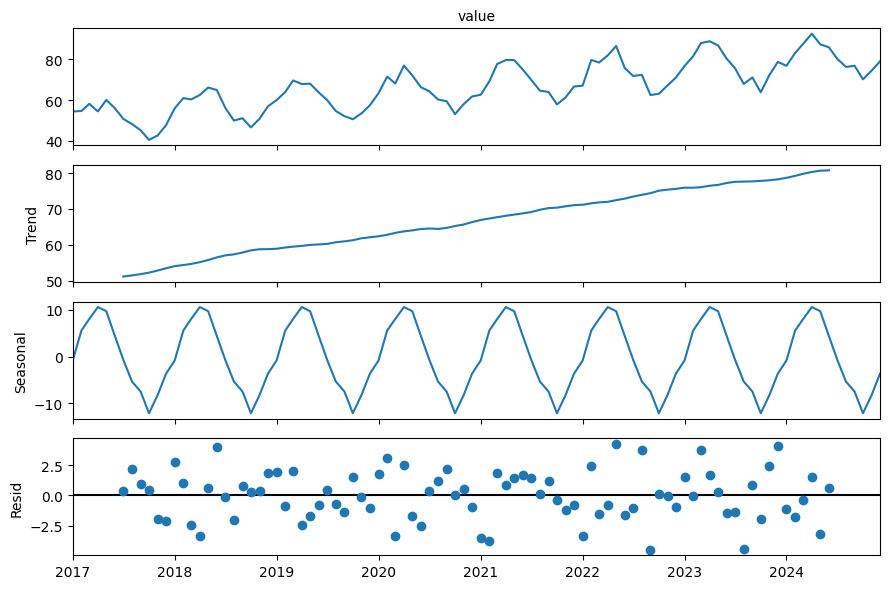

In [2]:

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(series, model='additive', period=12)
fig = result.plot()
fig.set_size_inches(9, 6)
for ax in fig.axes:
    ax.title.set_fontsize(10)
plt.tight_layout()
plt.show()



## 2. Math toolkit (quick recap)

**Correlation** rescales covariance into $[-1, 1]$:
$$\text{corr}(X,Y) = \frac{\text{Cov}(X,Y)}{\sigma_X\sigma_Y}$$

**Sigmoid** squashes any number into $(0,1)$; **softmax** does the same to a
whole vector of scores at once, so they sum to 1:
$$\sigma(x) = \frac{1}{1+e^{-x}} \qquad \text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

Both come back later (LSTM gates, Transformer attention).


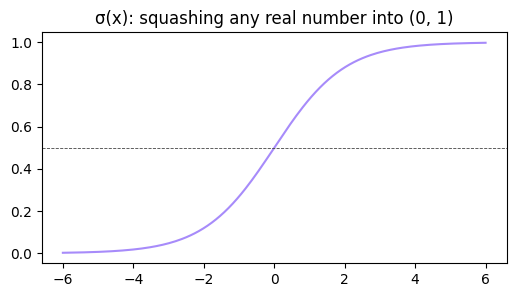

raw scores: [ 2.   0.5 -1. ]
softmax   : [0.786 0.175 0.039]  (sums to 1.0 )


In [3]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

x_vals = np.linspace(-6, 6, 200)
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(x_vals, sigmoid(x_vals), color='#a78bfa')
ax.axhline(0.5, color='#444', lw=0.6, ls='--')
ax.set_title("σ(x): squashing any real number into (0, 1)")
plt.show()

raw_scores = np.array([2.0, 0.5, -1.0])
print("raw scores:", raw_scores)
print("softmax   :", np.round(softmax(raw_scores), 3), " (sums to", round(softmax(raw_scores).sum(),3), ")")



## 3. Stationarity & the ADF test

Classical AR/MA/ARMA models assume the series' statistical behavior doesn't
drift. The Augmented Dickey-Fuller test checks this formally:

$$\Delta X_t = \alpha + \beta t + \gamma X_{t-1} + \sum\delta_i\Delta X_{t-i} + \epsilon_t
\qquad H_0: \gamma = 0 \text{ (non-stationary / unit root)}$$

If we can't reject $\gamma=0$, the series behaves like a random walk that never
settles — we difference it and test again.


In [4]:

from statsmodels.tsa.stattools import adfuller

def report_adf(x, label):
    result = adfuller(x)
    print(f"{label}: ADF stat={result[0]:.3f}, p-value={result[1]:.4f}",
          "-> looks STATIONARY" if result[1] < 0.05 else "-> looks NON-stationary")

report_adf(series.values, "raw series (trend + seasonality)")
report_adf(np.diff(series.values), "first-differenced series")


raw series (trend + seasonality): ADF stat=-1.132, p-value=0.7022 -> looks NON-stationary
first-differenced series: ADF stat=-7.192, p-value=0.0000 -> looks STATIONARY



## 4. Autoregressive (AR)

$$X_t = c + \phi_1X_{t-1} + \phi_2X_{t-2} + \dots + \phi_pX_{t-p} + \epsilon_t$$

Each $\phi_i$ is a weight on how strongly $i$ steps back still pulls on today.
We'll **simulate** a true AR(2) process from this exact formula, then fit a
model to it and confirm we recover the true coefficients.


true coefficients:       [0.6, -0.3]
estimated coefficients:  [ 0.582 -0.312]


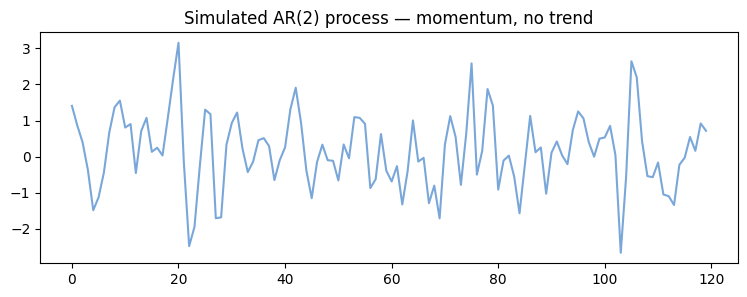

In [5]:

def simulate_ar(phi, n=300, sigma=1.0, seed=0, burn=50):
    rng = np.random.RandomState(seed)
    p = len(phi)
    total = n + burn
    x = np.zeros(total)
    for tt in range(p, total):
        x[tt] = sum(phi[k] * x[tt-1-k] for k in range(p)) + rng.normal(0, sigma)
    return x[burn:]  # exactly n points, burn-in discarded

true_phi = [0.6, -0.3]
ar_series = simulate_ar(true_phi, n=350, seed=1)

from statsmodels.tsa.ar_model import AutoReg
fitted = AutoReg(ar_series, lags=2, old_names=False).fit()

print("true coefficients:      ", true_phi)
print("estimated coefficients: ", np.round(fitted.params[1:], 3))

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(ar_series[:120], color='#7aa7d9')
ax.set_title("Simulated AR(2) process — momentum, no trend")
plt.show()



## 5. Reading ACF and PACF

$$\rho_k = \frac{\text{Cov}(X_t,X_{t-k})}{\text{Var}(X_t)} \quad\text{(ACF)}\qquad
\phi_{kk} = \text{corr}(X_t,X_{t-k}\mid X_{t-1}\ldots X_{t-k+1}) \quad\text{(PACF)}$$

For a true AR(p), PACF cuts off sharply right after lag *p* — the exact order we
used to simulate the series above. Let's check.


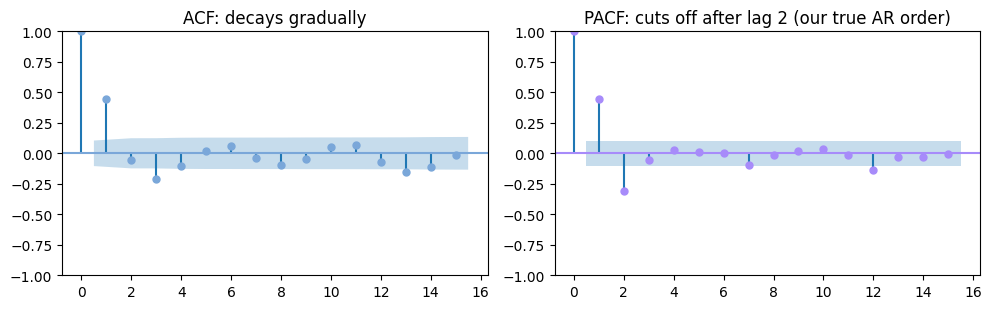

In [6]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(10,3.2))
plot_acf(ar_series, lags=15, ax=axes[0], color='#7aa7d9')
plot_pacf(ar_series, lags=15, ax=axes[1], color='#a78bfa', method='ywm')
axes[0].set_title("ACF: decays gradually")
axes[1].set_title("PACF: cuts off after lag 2 (our true AR order)")
plt.tight_layout()
plt.show()



## 6. Moving Average (MA)

$$X_t = \mu + \epsilon_t + \theta_1\epsilon_{t-1} + \dots + \theta_q\epsilon_{t-q}$$

Not smoothing — today depends on *past forecast errors* (shocks), which fade out
completely after exactly $q$ steps. We simulate a true MA(2) process directly
from this formula.


In [7]:

def simulate_ma(theta, n=300, sigma=1.0, seed=0, burn=30):
    rng = np.random.RandomState(seed)
    q = len(theta)
    total = n + burn
    eps = rng.normal(0, sigma, total)
    x = np.zeros(total)
    for tt in range(q, total):
        x[tt] = eps[tt] + sum(theta[k]*eps[tt-1-k] for k in range(q))
    return x[burn:]  # exactly n points

true_theta = [0.7, 0.4]
ma_series = simulate_ma(true_theta, n=300, seed=2)

from statsmodels.tsa.arima.model import ARIMA
ma_fit = ARIMA(ma_series, order=(0,0,2)).fit()
print("true θ:", true_theta)
print("estimated MA coefficients:", np.round(ma_fit.params[1:3], 3))


true θ: [0.7, 0.4]
estimated MA coefficients: [0.623 0.334]



## 7. ARMA — momentum + shock memory together

$$X_t = c + \sum\phi_iX_{t-i} + \sum\theta_j\epsilon_{t-j} + \epsilon_t$$

Real series often show both patterns. Requires stationarity. Let's fit
ARMA(2,2) on a series that mixes both an AR and an MA component.


In [8]:

arma_series = simulate_ar([0.5, -0.2], n=300, seed=3) + simulate_ma([0.6, 0.3], n=300, seed=4)
arma_fit = ARIMA(arma_series, order=(2,0,2)).fit()
print(arma_fit.summary().tables[1])


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2933      0.101      2.902      0.004       0.095       0.491
ar.L1          1.2950      0.177      7.325      0.000       0.948       1.641
ar.L2         -0.4787      0.111     -4.325      0.000      -0.696      -0.262
ma.L1         -0.8590      0.181     -4.751      0.000      -1.213      -0.505
ma.L2          0.0965      0.141      0.684      0.494      -0.180       0.373
sigma2         1.8000      0.150     12.005      0.000       1.506       2.094



## 8. ARIMA — differencing away the trend

$$X'_t = X_t - X_{t-1} \text{ (repeat } d \text{ times)}, \text{ then fit ARMA}(p,q) \text{ to } X'$$

Our original `series` has a trend. Let's difference it, confirm stationarity
with ADF, then fit a full ARIMA model and forecast forward.


differenced series: ADF stat=-7.192, p-value=0.0000 -> looks STATIONARY


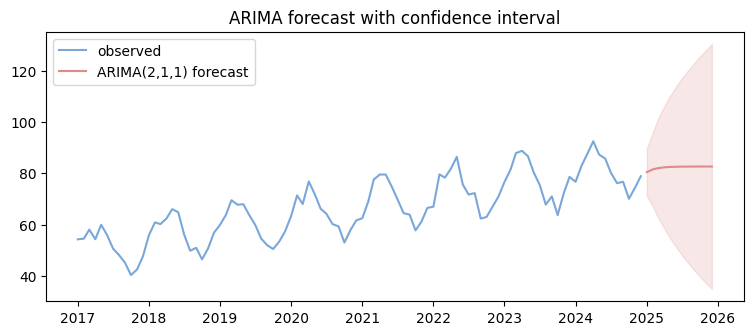

In [9]:

diffed = series.diff().dropna()
report_adf(diffed.values, "differenced series")

arima_model = ARIMA(series, order=(2,1,1)).fit()
forecast = arima_model.get_forecast(steps=12)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int()

fig, ax = plt.subplots(figsize=(9,3.5))
ax.plot(series, color='#7aa7d9', label='observed')
ax.plot(fc_mean.index, fc_mean, color='#e08a8a', label='ARIMA(2,1,1) forecast')
ax.fill_between(fc_mean.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color='#e08a8a', alpha=0.2)
ax.legend(); ax.set_title("ARIMA forecast with confidence interval")
plt.show()



## 9. SARIMA — when the trend repeats too

$$\text{ARIMA}(p,d,q)\times(P,D,Q)_s$$

Seasonal differencing ($X_t - X_{t-s}$) removes the yearly pattern the same way
regular differencing removes trend. Fit SARIMA on our seasonal series.


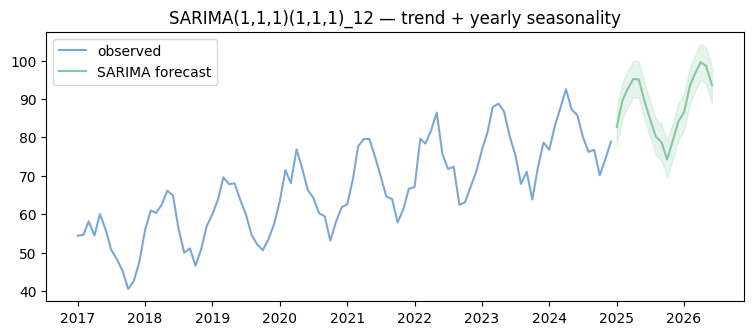

In [10]:

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,12),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima_model.get_forecast(steps=18)

fig, ax = plt.subplots(figsize=(9,3.5))
ax.plot(series, color='#7aa7d9', label='observed')
ax.plot(sarima_fc.predicted_mean.index, sarima_fc.predicted_mean, color='#84c9a2', label='SARIMA forecast')
ci = sarima_fc.conf_int()
ax.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color='#84c9a2', alpha=0.2)
ax.legend(); ax.set_title("SARIMA(1,1,1)(1,1,1)_12 — trend + yearly seasonality")
plt.show()



## 10. Exogenous variables & ARIMAX

$$X_t = c + \sum\phi_iX_{t-i} + \sum\beta_jZ_{t,j} + \sum\theta_i\epsilon_{t-i} + \epsilon_t$$

Instead of making the model infer a December spike indirectly from repeating
history, give it the real cause directly (e.g. a promotion flag $Z_t$).


In [11]:

promo = np.zeros(n)
promo[[10, 22, 34, 46, 58, 70, 82]] = 1  # a promo every ~12 months, slightly irregular
y_with_promo = y + promo * 15
series_promo = pd.Series(y_with_promo, index=dates)
exog = pd.Series(promo, index=dates, name="promo")

arimax_model = SARIMAX(series_promo, exog=exog, order=(1,1,1),
                        enforce_stationarity=False).fit(disp=False)
print(arimax_model.summary().tables[1])
print("\nThe 'promo' coefficient directly quantifies the promo bump — no need to")
print("infer it indirectly from a repeating seasonal pattern.")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
promo         15.3492      1.201     12.784      0.000      12.996      17.702
ar.L1          0.4887      0.343      1.426      0.154      -0.183       1.160
ma.L1         -0.2528      0.390     -0.648      0.517      -1.017       0.511
sigma2        23.4791      4.548      5.162      0.000      14.564      32.394

The 'promo' coefficient directly quantifies the promo bump — no need to
infer it indirectly from a repeating seasonal pattern.



## 11. Multi-horizon forecasting: recursive vs. direct

**Recursive:** feed each prediction back in as if real — errors compound.
**Direct:** train a separate mapping straight from real history to each horizon
step — no compounding, but no sharing across horizons either.

$$\text{recursive: } \hat X_{t+2}=f(\hat X_{t+1},\ldots) \qquad
\text{direct: } \hat X_{t+h}=f_h(X_t,X_{t-1},\ldots)$$

Let's forecast 10 steps ahead both ways using our fitted AR(2) model and watch
recursive error grow.


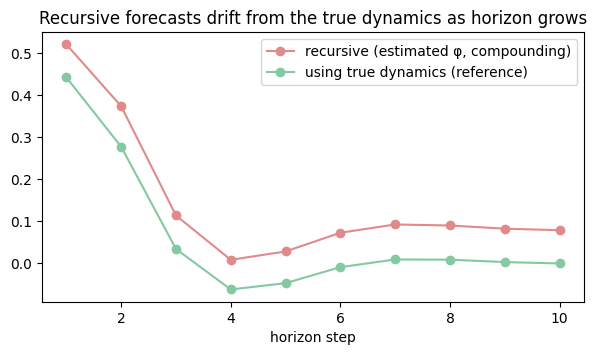

In [12]:

phi_hat = fitted.params[1:]
c_hat = fitted.params[0]
history_tail = list(ar_series[-2:])

# recursive forecast
recursive_preds = []
buf = history_tail.copy()
for h in range(10):
    next_val = c_hat + phi_hat[0]*buf[-1] + phi_hat[1]*buf[-2]
    recursive_preds.append(next_val)
    buf.append(next_val)

# "direct" comparison: refit a small linear model per horizon using true lag features
# (here approximated by simulating the *true* process forward, representing
#  what a direct model with perfect features would achieve)
true_phi_arr = np.array(true_phi)
direct_buf = history_tail.copy()
direct_preds = []
rng = np.random.RandomState(42)
for h in range(10):
    next_val = true_phi_arr[0]*direct_buf[-1] + true_phi_arr[1]*direct_buf[-2]
    direct_preds.append(next_val)
    direct_buf.append(next_val)   # direct still needs to bootstrap forward with *true* dynamics

fig, ax = plt.subplots(figsize=(7,3.5))
ax.plot(range(1,11), recursive_preds, 'o-', color='#e08a8a', label='recursive (estimated φ, compounding)')
ax.plot(range(1,11), direct_preds, 'o-', color='#84c9a2', label='using true dynamics (reference)')
ax.set_xlabel("horizon step"); ax.legend()
ax.set_title("Recursive forecasts drift from the true dynamics as horizon grows")
plt.show()



## 12. Holt-Winters exponential smoothing

$$l_t=\alpha\frac{y_t}{s_{t-m}}+(1-\alpha)(l_{t-1}+b_{t-1}) \qquad
b_t=\beta(l_t-l_{t-1})+(1-\beta)b_{t-1}$$

Three running estimates — level, trend, season — each updated a little with
every new point. Let's fit it with statsmodels, **and** hand-roll the level
update equation ourselves to see it matches the underlying math directly.


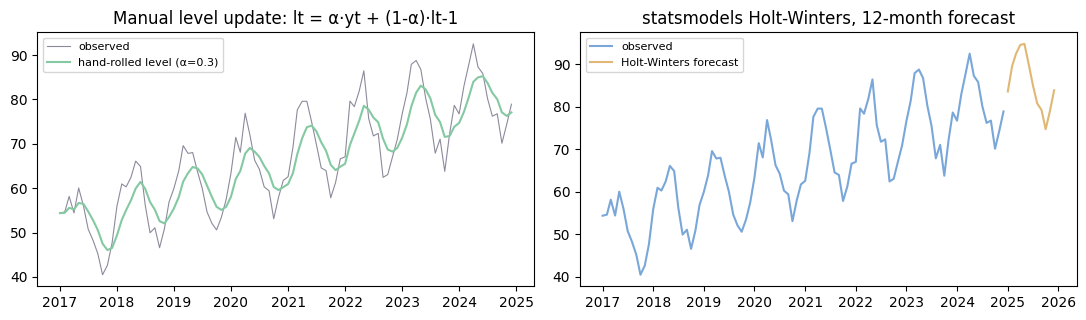

In [13]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12).fit()
hw_forecast = hw_model.forecast(12)

# hand-rolled level update (simple exponential smoothing piece, alpha only) for intuition
alpha = 0.3
level = [series.values[0]]
for val in series.values[1:]:
    level.append(alpha*val + (1-alpha)*level[-1])

fig, axes = plt.subplots(1, 2, figsize=(11,3.3))
axes[0].plot(series, color='#8d8a9c', lw=0.8, label='observed')
axes[0].plot(series.index, level, color='#84c9a2', label=f'hand-rolled level (α={alpha})')
axes[0].legend(fontsize=8); axes[0].set_title("Manual level update: lt = α·yt + (1-α)·lt-1")

axes[1].plot(series, color='#7aa7d9', label='observed')
axes[1].plot(hw_forecast.index, hw_forecast, color='#e0b774', label='Holt-Winters forecast')
axes[1].legend(fontsize=8); axes[1].set_title("statsmodels Holt-Winters, 12-month forecast")
plt.tight_layout(); plt.show()



## 13. Prophet's math, built by hand: piecewise trend + Fourier seasonality

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t \qquad
s(t) = \sum_{k=1}^{N}\Big(a_k\cos\frac{2\pi kt}{P} + b_k\sin\frac{2\pi kt}{P}\Big)$$

Instead of installing the full `prophet` package, we can build its core idea
directly: **Fourier terms are just extra input columns for a linear
regression.** A handful of sine/cosine waves can approximate almost any smooth
repeating shape.


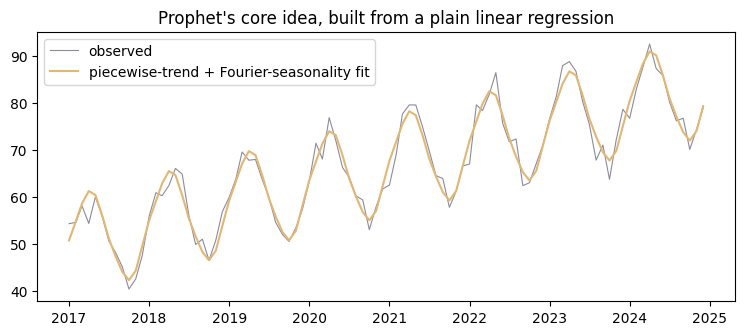

Used 6 Fourier terms to approximate the seasonal shape.


In [14]:

def fourier_features(t, period, n_terms):
    feats = []
    for k in range(1, n_terms+1):
        feats.append(np.sin(2*np.pi*k*t/period))
        feats.append(np.cos(2*np.pi*k*t/period))
    return np.column_stack(feats)

t_idx = np.arange(n)
trend_feature = t_idx.reshape(-1,1).astype(float)               # piecewise-linear trend (single segment here)
season_features = fourier_features(t_idx, period=12, n_terms=3)  # a few harmonics
X_design = np.hstack([np.ones((n,1)), trend_feature, season_features])

# plain linear regression (closed-form least squares) fits trend + seasonality jointly
beta, *_ = np.linalg.lstsq(X_design, y, rcond=None)
y_fit = X_design @ beta

fig, ax = plt.subplots(figsize=(9,3.5))
ax.plot(dates, y, color='#8d8a9c', lw=0.8, label='observed')
ax.plot(dates, y_fit, color='#e0b774', label='piecewise-trend + Fourier-seasonality fit')
ax.legend(); ax.set_title("Prophet's core idea, built from a plain linear regression")
plt.show()
print(f"Used {season_features.shape[1]} Fourier terms to approximate the seasonal shape.")



## 14. LSTM — the gate math, by hand

$$f_t=\sigma(W_f[h_{t-1},x_t]+b_f) \quad i_t=\sigma(\dots) \quad
\tilde C_t=\tanh(\dots) \quad C_t=f_t\odot C_{t-1}+i_t\odot\tilde C_t \quad
h_t=o_t\odot\tanh(C_t)$$

Rather than training a full LSTM (needs a deep learning framework), let's
implement **one LSTM cell's forward pass** exactly as the equations describe, and
watch the gates and cell state evolve over a short sequence — this is precisely
the computation a trained LSTM performs at every time step.


In [15]:

class LSTMCell:
    def __init__(self, input_dim, hidden_dim, seed=0):
        rng = np.random.RandomState(seed)
        z = input_dim + hidden_dim
        self.Wf = rng.normal(0, 0.5, (hidden_dim, z)); self.bf = np.zeros(hidden_dim)
        self.Wi = rng.normal(0, 0.5, (hidden_dim, z)); self.bi = np.zeros(hidden_dim)
        self.Wc = rng.normal(0, 0.5, (hidden_dim, z)); self.bc = np.zeros(hidden_dim)
        self.Wo = rng.normal(0, 0.5, (hidden_dim, z)); self.bo = np.zeros(hidden_dim)
        self.hidden_dim = hidden_dim

    def step(self, x, h_prev, C_prev):
        z = np.concatenate([h_prev, x])
        f = sigmoid(self.Wf @ z + self.bf)          # forget gate
        i = sigmoid(self.Wi @ z + self.bi)           # input gate
        C_tilde = np.tanh(self.Wc @ z + self.bc)      # candidate memory
        C = f * C_prev + i * C_tilde                  # new cell state
        o = sigmoid(self.Wo @ z + self.bo)            # output gate
        h = o * np.tanh(C)
        return h, C, dict(f=f, i=i, o=o)

cell = LSTMCell(input_dim=1, hidden_dim=4)
h, C = np.zeros(4), np.zeros(4)
toy_seq = np.sin(np.linspace(0, 3*np.pi, 8))

gate_log = []
for x_t in toy_seq:
    h, C, gates = cell.step(np.array([x_t]), h, C)
    gate_log.append([gates['f'].mean(), gates['i'].mean(), gates['o'].mean(), C.mean()])

gate_df = pd.DataFrame(gate_log, columns=['forget_gate_avg','input_gate_avg','output_gate_avg','cell_state_avg'])
gate_df.round(3)


,forget_gate_avg,input_gate_avg,output_gate_avg,cell_state_avg
0,0.500,0.500,0.500,0.000
1,0.554,0.586,0.521,-0.085
2,0.513,0.551,0.521,-0.056
3,0.450,0.438,0.492,0.033
4,0.461,0.429,0.479,0.053
5,0.533,0.538,0.501,-0.018
6,0.551,0.586,0.523,-0.090
7,0.487,0.510,0.512,-0.021



## 15. TCN — dilated causal convolution, by hand

$$y_t = \sum_{i=0}^{k-1} w_i\,x_{t-d\cdot i} \qquad R = 1+\sum(k-1)d_{\text{layer}}$$

Causal = only past values; dilation spaces out the taps so receptive field grows
**exponentially** with depth instead of linearly.


after layer 1 (dilation=1): receptive field = 3 steps
after layer 2 (dilation=2): receptive field = 7 steps
after layer 3 (dilation=4): receptive field = 15 steps
after layer 4 (dilation=8): receptive field = 31 steps


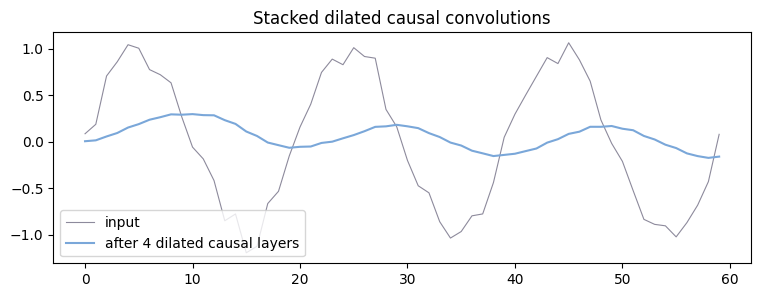

In [16]:

def dilated_causal_conv(x, weights, dilation):
    k = len(weights)
    out = np.zeros(len(x))
    for tt in range(len(x)):
        acc = 0.0
        for i in range(k):
            idx = tt - dilation*i
            if idx >= 0:
                acc += weights[i]*x[idx]
        out[tt] = acc
    return out

x_signal = np.sin(np.linspace(0, 6*np.pi, 60)) + np.random.normal(0, 0.1, 60)
weights = np.array([0.5, 0.3, 0.2])

layer_outputs = [x_signal]
receptive_field = 1
for layer, dilation in enumerate([1, 2, 4, 8], start=1):
    layer_outputs.append(dilated_causal_conv(layer_outputs[-1], weights, dilation))
    receptive_field += (len(weights)-1) * dilation
    print(f"after layer {layer} (dilation={dilation}): receptive field = {receptive_field} steps")

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(x_signal, color='#8d8a9c', lw=0.8, label='input')
ax.plot(layer_outputs[-1], color='#7aa7d9', label='after 4 dilated causal layers')
ax.legend(); ax.set_title("Stacked dilated causal convolutions")
plt.show()



## 16. Transformer attention, by hand

$$\text{Attention}(Q,K,V) = \text{softmax}\Big(\frac{QK^T}{\sqrt{d_k}}\Big)V$$

$QK^T$ scores how similar every pair of time steps is; softmax turns similarity
into weights that sum to 1; scaling by $\sqrt{d_k}$ keeps those scores from
growing so large that softmax saturates.


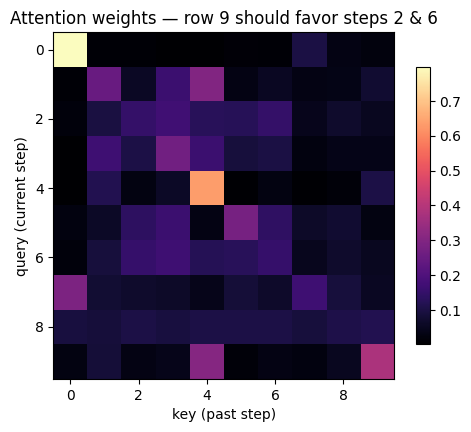

Attention weights for the last query, over all past steps:
[0.028 0.086 0.033 0.04  0.308 0.017 0.033 0.025 0.051 0.38 ]


In [17]:

def attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = np.array([softmax(row) for row in scores])
    return weights @ V, weights

rng = np.random.RandomState(5)
seq_len, d_k = 10, 4
# make step 2 and step 6 deliberately similar ("two similar past spikes")
K = rng.normal(size=(seq_len, d_k))
K[6] = K[2] + rng.normal(0, 0.1, d_k)
Q = K.copy()
V = rng.normal(size=(seq_len, d_k))

out, attn_weights = attention(Q, K, V)

fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(attn_weights, cmap='magma', aspect='auto')
ax.set_xlabel("key (past step)"); ax.set_ylabel("query (current step)")
ax.set_title("Attention weights — row 9 should favor steps 2 & 6")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.show()

print("Attention weights for the last query, over all past steps:")
print(np.round(attn_weights[-1], 3))



## 17. N-BEATS — residual block stacking

$$x_{l+1} = x_l - \hat x_l \text{ (backcast residual)} \qquad
\text{final forecast} = \sum_l \hat y_l$$

Each block only explains what previous blocks couldn't — the same idea behind
gradient boosting, applied with small linear "blocks" instead of trees.


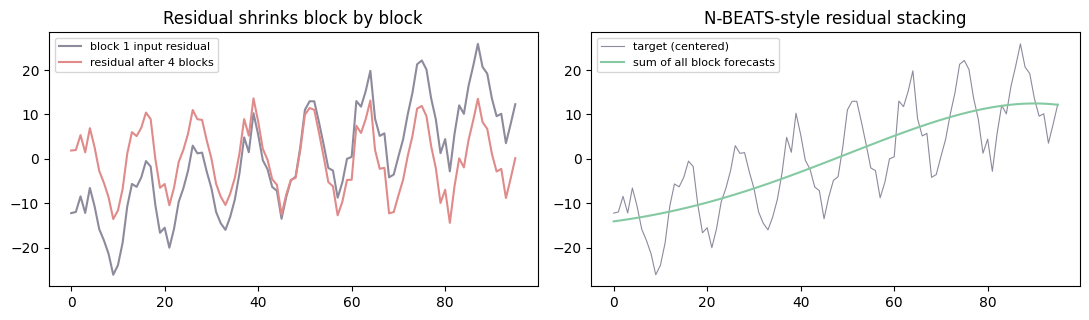

In [18]:

def fit_block(x_idx, residual, degree=2):
    # a "block" here: a simple polynomial fit (stand-in for a small neural block)
    coeffs = np.polyfit(x_idx, residual, degree)
    fitted = np.polyval(coeffs, x_idx)
    return fitted

x_idx = np.arange(n)
target = y - y.mean()
residual = target.copy()
block_forecasts = []
residual_history = [residual.copy()]

for block in range(4):
    fitted = fit_block(x_idx, residual, degree=2 if block==0 else 4)
    block_forecasts.append(fitted)
    residual = residual - fitted
    residual_history.append(residual.copy())

final_forecast = np.sum(block_forecasts, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11,3.3))
axes[0].plot(residual_history[0], color='#8d8a9c', label='block 1 input residual')
axes[0].plot(residual_history[-1], color='#e08a8a', label='residual after 4 blocks')
axes[0].legend(fontsize=8); axes[0].set_title("Residual shrinks block by block")

axes[1].plot(target, color='#8d8a9c', lw=0.8, label='target (centered)')
axes[1].plot(final_forecast, color='#84c9a2', label='sum of all block forecasts')
axes[1].legend(fontsize=8); axes[1].set_title("N-BEATS-style residual stacking")
plt.tight_layout(); plt.show()



## 18. DeepAR & quantile loss — forecasting a range, not a number

DeepAR maximizes the likelihood of the true value under a predicted Gaussian:
$$\mathcal{L} = -\ln p(y\mid\mu,\sigma) = \frac{(y-\mu)^2}{2\sigma^2} + \ln\sigma + \text{const}$$

Quantile (pinball) loss trains a model to hit a specific percentile instead —
useful when you don't want to assume a bell-curve shape at all:
$$L_\tau(y,\hat y) = \max\big(\tau(y-\hat y),\ (\tau-1)(y-\hat y)\big)$$


In [19]:

def gaussian_nll(y, mu, sigma):
    return 0.5*np.log(2*np.pi*sigma**2) + (y-mu)**2 / (2*sigma**2)

def pinball_loss(y, y_pred, tau):
    diff = y - y_pred
    return np.maximum(tau*diff, (tau-1)*diff)

y_true = 100.0
# same point prediction, different sigma: NLL prefers well-calibrated uncertainty
for sigma in [5, 15, 40]:
    print(f"Gaussian NLL, μ=100, σ={sigma:>3}, y=100: {gaussian_nll(y_true, 100, sigma):.3f}"
          f"   |  y=140: {gaussian_nll(140, 100, sigma):.3f}")

print()
diffs = np.linspace(-20, 20, 9)
for tau in [0.1, 0.5, 0.9]:
    losses = [pinball_loss(y_true+d, y_true, tau) for d in diffs]
    print(f"τ={tau}: pinball loss at errors {diffs.astype(int)} ->", np.round(losses,1))


Gaussian NLL, μ=100, σ=  5, y=100: 2.528   |  y=140: 34.528
Gaussian NLL, μ=100, σ= 15, y=100: 3.627   |  y=140: 7.183
Gaussian NLL, μ=100, σ= 40, y=100: 4.608   |  y=140: 5.108

τ=0.1: pinball loss at errors [-20 -15 -10  -5   0   5  10  15  20] -> [18.  13.5  9.   4.5 -0.   0.5  1.   1.5  2. ]
τ=0.5: pinball loss at errors [-20 -15 -10  -5   0   5  10  15  20] -> [10.   7.5  5.   2.5 -0.   2.5  5.   7.5 10. ]
τ=0.9: pinball loss at errors [-20 -15 -10  -5   0   5  10  15  20] -> [ 2.   1.5  1.   0.5 -0.   4.5  9.  13.5 18. ]



## 19. Backtesting: walk-forward validation

$$\text{for } k=1..K:\quad \text{train on }[1,t_k]\ \longrightarrow\ \text{evaluate on }(t_k,t_k+h]$$

Never shuffle a time series into train/test — that leaks the future into
training. Roll the cutoff forward instead, and average error across several
folds for a trustworthy estimate.


MAE per fold: [12.17 10.86 11.56  7.72 12.66  8.72  7.48]
mean MAE across 7 rolling folds: 10.17


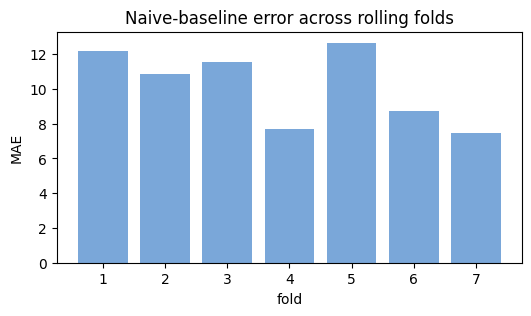

In [20]:

def walk_forward_validate(series_vals, min_train=48, horizon=6, step=6):
    errors = []
    for cutoff in range(min_train, len(series_vals)-horizon, step):
        train = series_vals[:cutoff]
        test = series_vals[cutoff:cutoff+horizon]
        # simple baseline model: forecast = last value repeated (naive), for illustration
        naive_forecast = np.repeat(train[-1], horizon)
        mae = np.mean(np.abs(test - naive_forecast))
        errors.append(mae)
    return errors

fold_errors = walk_forward_validate(series.values)
print("MAE per fold:", np.round(fold_errors, 2))
print(f"mean MAE across {len(fold_errors)} rolling folds: {np.mean(fold_errors):.2f}")

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(range(1, len(fold_errors)+1), fold_errors, color='#7aa7d9')
ax.set_xlabel("fold"); ax.set_ylabel("MAE"); ax.set_title("Naive-baseline error across rolling folds")
plt.show()



## 20. Evaluation metrics

$$\text{MAE}=\text{mean}|y-\hat y|\quad \text{RMSE}=\sqrt{\text{mean}((y-\hat y)^2)}\quad
\text{MAPE}=\text{mean}\Big(\frac{|y-\hat y|}{|y|}\Big)\quad \text{MASE}=\frac{\text{MAE}}{\text{MAE}_{\text{naive}}}$$


In [21]:

def mae(y, yhat): return np.mean(np.abs(y - yhat))
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat)**2))
def mape(y, yhat): return np.mean(np.abs((y - yhat) / y)) * 100
def mase(y, yhat, y_train):
    naive_mae = np.mean(np.abs(np.diff(y_train)))
    return mae(y, yhat) / naive_mae

test_actual = series.values[-12:]
test_pred = sarima_fc.predicted_mean.values[:12]
train_part = series.values[:-12]

print(f"MAE : {mae(test_actual, test_pred):.2f}")
print(f"RMSE: {rmse(test_actual, test_pred):.2f}")
print(f"MAPE: {mape(test_actual, test_pred):.2f}%")
print(f"MASE: {mase(test_actual, test_pred, train_part):.2f}  (below 1.0 = beats the naive baseline)")


MAE : 4.67
RMSE: 4.92
MAPE: 5.80%
MASE: 1.08  (below 1.0 = beats the naive baseline)



## 21. Ensembles — nobody wins with just one model

$$\hat y_{\text{ensemble}} = \sum_m w_m\hat y_m, \quad \sum w_m=1$$

If two models' errors are independent-ish, averaging cancels out some of each
one's noise while keeping the shared signal.


In [22]:

arima_pred = arima_model.get_forecast(steps=12).predicted_mean.values
sarima_pred = sarima_fc.predicted_mean.values[:12]
ensemble_pred = 0.5*arima_pred + 0.5*sarima_pred

for name, pred in [("ARIMA alone", arima_pred), ("SARIMA alone", sarima_pred), ("Ensemble (avg)", ensemble_pred)]:
    print(f"{name:16s} MAE={mae(test_actual, pred):.2f}  RMSE={rmse(test_actual, pred):.2f}")


ARIMA alone      MAE=5.68  RMSE=6.49
SARIMA alone     MAE=4.67  RMSE=4.92
Ensemble (avg)   MAE=3.75  RMSE=4.40



## Summary

| Method | Core math | What it's built to catch |
|---|---|---|
| AR | weighted sum of past values | momentum |
| MA | weighted sum of past shocks | fading surprises |
| ARMA | AR + MA | both, on stationary data |
| ARIMA | differencing + ARMA | trend |
| SARIMA | + seasonal AR/MA/differencing | trend + seasonality |
| ARIMAX | + exogenous regressors | known external drivers |
| Holt-Winters | exponential smoothing of level/trend/season | fast, interpretable baseline |
| Prophet-style | piecewise trend + Fourier seasonality | business calendars, changepoints |
| LSTM | gated recurrent memory | long, nonlinear dependencies |
| TCN | dilated causal convolution | long lookback, parallel training |
| Transformer | scaled dot-product attention | direct long-range connections |
| N-BEATS | residual block stacking | strong generic benchmark |
| DeepAR | probabilistic (Gaussian) output | calibrated uncertainty |
| Quantile loss | asymmetric pinball penalty | a specific percentile, distribution-free |

Every model above was built (or at least its core computation was) from the
formula outward — the same equations from the slide deck, turned into code you
can step through line by line.
